In [1]:
import os
import glob
import netCDF4
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib import gridspec
import cartopy.crs as ccrs
import cartopy.feature
import seaborn as sns

import wrf
from cartopy.mpl.gridliner import LATITUDE_FORMATTER, LONGITUDE_FORMATTER
import matplotlib.ticker as mticker
import matplotlib.colors

import matplotlib as mpl

from metpy import calc as mpcalc

In [2]:
######################
# FUNCTIONS
######################

def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return array[idx]

In [3]:
######################
# CHARGE PROCESSES
print('Charging Ant hist...')

#Parameters
folder_mod = '/capstor/scratch/cscs/gsergi/OUTPUT_PGW_20220315/ANT_20220315_'
domain = 'd01'
acc_t = 1440 #minutes
ini_date_idx=0
#end_date_idx=0

###load data###
outhist_files = '/outhist/outhist_'+domain+'_*'# Load netcdf

################
#hist
wrflist_oh = []
proj = 'hist'
print('Total: ' + str(np.size(glob.glob(folder_mod+proj+outhist_files))))
for i,ncdf_oh in enumerate(np.sort(glob.glob(folder_mod+proj+outhist_files))):
        print(i, end="\r")
        wrflist_oh.append(netCDF4.Dataset(ncdf_oh))
    
# Get surface variables
t2_ant_hist = wrf.getvar(wrflist_oh, 'T2', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:] - 273.15

# Extract the pressure, geopotential height, and wind variables
Ppertubation_ant_hist = wrf.getvar(wrflist_oh, 'P', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
PB_ant_hist = wrf.getvar(wrflist_oh, 'PB', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
P_ant_hist = (Ppertubation_ant_hist + PB_ant_hist)

PHperturbation_ant_hist = wrf.getvar(wrflist_oh, 'PH', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
PHB_ant_hist = wrf.getvar(wrflist_oh, 'PHB', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
Z_ant_hist = (PHperturbation_ant_hist + PHB_ant_hist)/9.8
Z_ant_hist_unstg = wrf.destagger(Z_ant_hist, stagger_dim=1)
Z_ant_hist_stg = np.diff(Z_ant_hist, axis=1)

#P_HYD_ant_hist = wrf.getvar(wrflist_oh, 'P_HYD', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
Q_ant_hist = wrf.getvar(wrflist_oh, 'QVAPOR', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
PT_ant_hist = wrf.getvar(wrflist_oh, 'T', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:] + 270
T_ant_hist = PT_ant_hist * (P_ant_hist/100000)**0.286
U_ant_hist = wrf.getvar(wrflist_oh, 'U', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
V_ant_hist = wrf.getvar(wrflist_oh, 'V', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
W_ant_hist = wrf.getvar(wrflist_oh, 'W', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
U_ant_hist_unstg = wrf.destagger(U_ant_hist, stagger_dim=3)
V_ant_hist_unstg = wrf.destagger(V_ant_hist, stagger_dim=2)
W_ant_hist_unstg = wrf.destagger(W_ant_hist, stagger_dim=1)

#Calculate variables in pressure levels
g = 9.81 #m/s2
rgas = 287.058 # J/(kg-K) => m2/(s2 K)

P_sig_hist = P_ant_hist[:,:26,:,:]
Z_sig_hist = Z_ant_hist_unstg[:,:26,:,:]
Q_sig_hist = Q_ant_hist[:,:26,:,:]
T_sig_hist = T_ant_hist[:,:26,:,:]
PT_sig_hist = PT_ant_hist[:,:26,:,:]
U_sig_hist = U_ant_hist_unstg[:,:26,:,:]
V_sig_hist = V_ant_hist_unstg[:,:26,:,:]
W_sig_hist = W_ant_hist_unstg[:,:26,:,:]
Rho_sig_hist  = P_sig_hist/(rgas*T_sig_hist)
Omega_sig_hist = - W_sig_hist * Rho_sig_hist * g


################
#ssp245
wrflist_oh = []
proj = 'ssp245_new'
print('Total: ' + str(np.size(glob.glob(folder_mod+proj+outhist_files))))
for i,ncdf_oh in enumerate(np.sort(glob.glob(folder_mod+proj+outhist_files))):
        print(i, end="\r")
        wrflist_oh.append(netCDF4.Dataset(ncdf_oh))
    
# Get surface variables
t2_ant_hist = wrf.getvar(wrflist_oh, 'T2', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:] - 273.15

# Extract the pressure, geopotential height, and wind variables
Ppertubation_ant_ssp245 = wrf.getvar(wrflist_oh, 'P', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
PB_ant_ssp245 = wrf.getvar(wrflist_oh, 'PB', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
P_ant_ssp245 = (Ppertubation_ant_ssp245 + PB_ant_ssp245)

PHperturbation_ant_ssp245 = wrf.getvar(wrflist_oh, 'PH', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
PHB_ant_ssp245 = wrf.getvar(wrflist_oh, 'PHB', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
Z_ant_ssp245 = (PHperturbation_ant_ssp245 + PHB_ant_ssp245)/9.8
Z_ant_ssp245_unstg = wrf.destagger(Z_ant_ssp245, stagger_dim=1)
Z_ant_ssp245_stg = np.diff(Z_ant_ssp245, axis=1)

#P_HYD_ant_hist = wrf.getvar(wrflist_oh, 'P_HYD', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
Q_ant_ssp245 = wrf.getvar(wrflist_oh, 'QVAPOR', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
PT_ant_ssp245 = wrf.getvar(wrflist_oh, 'T', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:] + 270
T_ant_ssp245 = PT_ant_ssp245 * (P_ant_ssp245/100000)**0.286
U_ant_ssp245 = wrf.getvar(wrflist_oh, 'U', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
V_ant_ssp245 = wrf.getvar(wrflist_oh, 'V', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
W_ant_ssp245 = wrf.getvar(wrflist_oh, 'W', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
U_ant_ssp245_unstg = wrf.destagger(U_ant_ssp245, stagger_dim=3)
V_ant_ssp245_unstg = wrf.destagger(V_ant_ssp245, stagger_dim=2)
W_ant_ssp245_unstg = wrf.destagger(W_ant_ssp245, stagger_dim=1)

#Calculate variables in pressure levels
g = 9.81 #m/s2
rgas = 287.058 # J/(kg-K) => m2/(s2 K)

P_sig_ssp245 = P_ant_ssp245[:,:26,:,:]
Z_sig_ssp245 = Z_ant_ssp245_unstg[:,:26,:,:]
Q_sig_ssp245 = Q_ant_ssp245[:,:26,:,:]
T_sig_ssp245 = T_ant_ssp245[:,:26,:,:]
PT_sig_ssp245 = PT_ant_ssp245[:,:26,:,:]
U_sig_ssp245 = U_ant_ssp245_unstg[:,:26,:,:]
V_sig_ssp245 = V_ant_ssp245_unstg[:,:26,:,:]
W_sig_ssp245 = W_ant_ssp245_unstg[:,:26,:,:]
Rho_sig_ssp245  = P_sig_ssp245/(rgas*T_sig_ssp245)
Omega_sig_ssp245 = - W_sig_ssp245 * Rho_sig_ssp245 * g



################
#ssp585
wrflist_oh = []
proj = 'ssp585_new'
print('Total: ' + str(np.size(glob.glob(folder_mod+proj+outhist_files))))
for i,ncdf_oh in enumerate(np.sort(glob.glob(folder_mod+proj+outhist_files))):
        print(i, end="\r")
        wrflist_oh.append(netCDF4.Dataset(ncdf_oh))
    
# Get surface variables
t2_ant_hist = wrf.getvar(wrflist_oh, 'T2', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:] - 273.15

# Extract the pressure, geopotential height, and wind variables
Ppertubation_ant_ssp585 = wrf.getvar(wrflist_oh, 'P', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
PB_ant_ssp585 = wrf.getvar(wrflist_oh, 'PB', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
P_ant_ssp585 = (Ppertubation_ant_ssp585 + PB_ant_ssp585)

PHperturbation_ant_ssp585 = wrf.getvar(wrflist_oh, 'PH', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
PHB_ant_ssp585 = wrf.getvar(wrflist_oh, 'PHB', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
Z_ant_ssp585 = (PHperturbation_ant_ssp585 + PHB_ant_ssp585)/9.8
Z_ant_ssp585_unstg = wrf.destagger(Z_ant_ssp585, stagger_dim=1)
Z_ant_ssp585_stg = np.diff(Z_ant_ssp585, axis=1)

#P_HYD_ant_hist = wrf.getvar(wrflist_oh, 'P_HYD', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
Q_ant_ssp585 = wrf.getvar(wrflist_oh, 'QVAPOR', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
PT_ant_ssp585 = wrf.getvar(wrflist_oh, 'T', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:] + 270
T_ant_ssp585 = PT_ant_ssp585 * (P_ant_ssp585/100000)**0.286
U_ant_ssp585 = wrf.getvar(wrflist_oh, 'U', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
V_ant_ssp585 = wrf.getvar(wrflist_oh, 'V', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
W_ant_ssp585 = wrf.getvar(wrflist_oh, 'W', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
U_ant_ssp585_unstg = wrf.destagger(U_ant_ssp585, stagger_dim=3)
V_ant_ssp585_unstg = wrf.destagger(V_ant_ssp585, stagger_dim=2)
W_ant_ssp585_unstg = wrf.destagger(W_ant_ssp585, stagger_dim=1)

#Calculate variables in pressure levels
g = 9.81 #m/s2
rgas = 287.058 # J/(kg-K) => m2/(s2 K)

P_sig_ssp585 = P_ant_ssp585[:,:26,:,:]
Z_sig_ssp585 = Z_ant_ssp585_unstg[:,:26,:,:]
Q_sig_ssp585 = Q_ant_ssp585[:,:26,:,:]
T_sig_ssp585 = T_ant_ssp585[:,:26,:,:]
PT_sig_ssp585 = PT_ant_ssp585[:,:26,:,:]
U_sig_ssp585 = U_ant_ssp585_unstg[:,:26,:,:]
V_sig_ssp585 = V_ant_ssp585_unstg[:,:26,:,:]
W_sig_ssp585 = W_ant_ssp585_unstg[:,:26,:,:]
Rho_sig_ssp585  = P_sig_ssp585/(rgas*T_sig_ssp585)
Omega_sig_ssp585 = - W_sig_ssp585 * Rho_sig_ssp585 * g


    
######################
# ANT COORDINATES
# Get surface fix variables
height = wrf.getvar(wrflist_oh, 'HGT', timeidx=0, method="cat")[:,:]
# Get dimension
lats, lons = wrf.latlon_coords(t2_ant_hist)
x, y = wrf.ll_to_xy(wrflist_oh, lons, lats)
times = wrf.extract_times(wrflist_oh, timeidx=wrf.ALL_TIMES)

Charging Ant hist...
Total: 59
Total: 59
Total: 59


/users/gsergi/miniconda3/lib/python3.9/site-packages/wrf/latlonutils.py:434: RuntimeWarning: invalid value encountered in cast
  result = np.rint(result).astype(int)


In [4]:
########################################
#Calculate Heat Tendency Equation components (level simga = 2)
#######################################
Xdist = Ydist = 27000

#Levels to average
lev_bottom = 1
lev_top = 4

#Create weighting by elevation of each layer
Z_ant_weighting = np.empty_like(Z_ant_hist_stg[:,lev_bottom:lev_top, :, :])
for i in range(lev_top-lev_bottom):
    Z_ant_weighting[:,i,:,:] = Z_ant_hist_stg[:,lev_bottom + i, :, :] / Z_ant_hist_stg[:,lev_bottom:lev_top, :, :].sum(axis=1)


#########
# hist
#Advection in horizontal axis
dT_dx = (np.diff(np.sum(T_sig_hist[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1), axis=2)[:,:,:-1] + np.diff(np.sum(T_sig_hist[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1), axis=2)[:,:,1:]) / (Xdist)
dT_dy = (np.diff(np.sum(T_sig_hist[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1), axis=1)[:,:-1,:] + np.diff(np.sum(T_sig_hist[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1), axis=1)[:,1:,:]) / (Ydist)
Adv_hist = - (np.sum(U_sig_hist[:,lev_bottom:lev_top,1:-1,1:-1]*Z_ant_weighting[:,:,1:-1,1:-1], axis=1)*dT_dx[:,1:-1,:] + np.sum(V_sig_hist[:,lev_bottom:lev_top,1:-1,1:-1]*Z_ant_weighting[:,:,1:-1,1:-1], axis=1)*dT_dy[:,:,1:-1]) *86400/24 #units deg/hour
Adv_hist = Adv_hist[1:-1,:,:]

#Advection in vertical axis
dT_dz = ((T_sig_hist[:,lev_bottom-1,:,:] - T_sig_hist[:,lev_top+1,:,:]) / (Z_sig_hist[:,lev_bottom-1,:,:]-Z_sig_hist[:,lev_top+1,:,:]))
VAdv_hist = - (np.sum(W_sig_hist[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1) * dT_dz[:,:,:]) *86400/24 #units deg/hour
VAdv_hist = VAdv_hist[1:-1,1:-1,1:-1]

#Temperature Tendency
T_hist_sec = np.sum(T_sig_hist[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1)[:-1,1:-1,1:-1]
Tend_hist = (T_hist_sec[1:,:,:].values - T_hist_sec[:-1,:,:].values) /3 #units deg/hour

#Temperature Tendency
Res_hist = Tend_hist[:,:,:]- Adv_hist - VAdv_hist

#Temperature
T_hist = np.sum(T_sig_hist[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1)


#########
# ssp245
#Advection in horizontal axis
dT_dx = (np.diff(np.sum(T_sig_ssp245[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1), axis=2)[:,:,:-1] + np.diff(np.sum(T_sig_ssp245[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1), axis=2)[:,:,1:]) / (Xdist)
dT_dy = (np.diff(np.sum(T_sig_ssp245[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1), axis=1)[:,:-1,:] + np.diff(np.sum(T_sig_ssp245[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1), axis=1)[:,1:,:]) / (Ydist)
Adv_ssp245 = - (np.sum(U_sig_ssp245[:,lev_bottom:lev_top,1:-1,1:-1]*Z_ant_weighting[:,:,1:-1,1:-1], axis=1)*dT_dx[:,1:-1,:] + np.sum(V_sig_ssp245[:,lev_bottom:lev_top,1:-1,1:-1]*Z_ant_weighting[:,:,1:-1,1:-1], axis=1)*dT_dy[:,:,1:-1]) *86400/24 #units deg/hour
Adv_ssp245 = Adv_ssp245[1:-1,:,:]

#Advection in vertical axis
dT_dz = ((T_sig_ssp245[:,lev_bottom-1,:,:] - T_sig_ssp245[:,lev_top+1,:,:]) / (Z_sig_ssp245[:,lev_bottom-1,:,:]-Z_sig_ssp245[:,lev_top+1,:,:]))
VAdv_ssp245 = - (np.sum(W_sig_ssp245[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1) * dT_dz[:,:,:]) *86400/24 #units deg/hour
VAdv_ssp245 = VAdv_ssp245[1:-1,1:-1,1:-1]

#Temperature Tendency
T_ssp245_sec = np.sum(T_sig_ssp245[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1)[:-1,1:-1,1:-1]
Tend_ssp245 = (T_ssp245_sec[1:,:,:].values - T_ssp245_sec[:-1,:,:].values) /3 #units deg/hour
#Temperature Tendency
Res_ssp245 = Tend_ssp245[:,:,:]- Adv_ssp245 - VAdv_ssp245

#Temperature
T_ssp245 = np.sum(T_sig_ssp245[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1)


#########
# ssp585
#Advection in horizontal axis
dT_dx = (np.diff(np.sum(T_sig_ssp585[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1), axis=2)[:,:,:-1] + np.diff(np.sum(T_sig_ssp585[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1), axis=2)[:,:,1:]) / (Xdist)
dT_dy = (np.diff(np.sum(T_sig_ssp585[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1), axis=1)[:,:-1,:] + np.diff(np.sum(T_sig_ssp585[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1), axis=1)[:,1:,:]) / (Ydist)
Adv_ssp585 = - (np.sum(U_sig_ssp585[:,lev_bottom:lev_top,1:-1,1:-1]*Z_ant_weighting[:,:,1:-1,1:-1], axis=1)*dT_dx[:,1:-1,:] + np.sum(V_sig_ssp585[:,lev_bottom:lev_top,1:-1,1:-1]*Z_ant_weighting[:,:,1:-1,1:-1], axis=1)*dT_dy[:,:,1:-1]) *86400/24 #units deg/hour
Adv_ssp585 = Adv_ssp585[1:-1,:,:]

#Advection in vertical axis
dT_dz = ((T_sig_ssp585[:,lev_bottom-1,:,:] - T_sig_ssp585[:,lev_top+1,:,:]) / (Z_sig_ssp585[:,lev_bottom-1,:,:]-Z_sig_ssp585[:,lev_top+1,:,:]))
VAdv_ssp585 = - (np.sum(W_sig_ssp585[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1) * dT_dz[:,:,:]) *86400/24 #units deg/hour
VAdv_ssp585 = VAdv_ssp585[1:-1,1:-1,1:-1]

#Temperature Tendency
T_ssp585_sec = np.sum(T_sig_ssp585[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1)[:-1,1:-1,1:-1]
Tend_ssp585 = (T_ssp585_sec[1:,:,:].values - T_ssp585_sec[:-1,:,:].values) /3 #units deg/hour

#Temperature Tendency
Res_ssp585 = Tend_ssp585[:,:,:]- Adv_ssp585 - VAdv_ssp585

#Temperature
T_ssp585 = np.sum(T_sig_ssp585[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1)


In [7]:
########################################
#Calculate Heat Tendency Equation components (level simga = 2)
#######################################
Xdist = Ydist = 27000

#Levels to average
lev_bottom = 1
lev_top = 4

#Create weighting by elevation of each layer
Z_ant_weighting = np.empty_like(Z_ant_hist_stg[:,lev_bottom:lev_top, :, :])
for i in range(lev_top-lev_bottom):
    Z_ant_weighting[:,i,:,:] = Z_ant_hist_stg[:,lev_bottom + i, :, :] / Z_ant_hist_stg[:,lev_bottom:lev_top, :, :].sum(axis=1)

#########
# hist
#Advection in horizontal axis
dT_dx = (np.diff(np.sum(T_sig_hist[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1), axis=2)[:,:,:-1] + np.diff(np.sum(T_sig_hist[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1), axis=2)[:,:,1:]) / (Xdist)
dT_dy = (np.diff(np.sum(T_sig_hist[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1), axis=1)[:,:-1,:] + np.diff(np.sum(T_sig_hist[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1), axis=1)[:,1:,:]) / (Ydist)
Adv_hist = - (np.sum(U_sig_hist[:,lev_bottom:lev_top,1:-1,1:-1]*Z_ant_weighting[:,:,1:-1,1:-1], axis=1)*dT_dx[:,1:-1,:] + np.sum(V_sig_hist[:,lev_bottom:lev_top,1:-1,1:-1]*Z_ant_weighting[:,:,1:-1,1:-1], axis=1)*dT_dy[:,:,1:-1]) *86400/24 #units deg/hour
Adv_hist = Adv_hist[1:-1,:,:]

#Advection in vertical axis
dT_dz = ((T_sig_hist[:,lev_bottom-1,:,:] - T_sig_hist[:,lev_top+1,:,:]) / (Z_sig_hist[:,lev_bottom-1,:,:]-Z_sig_hist[:,lev_top+1,:,:]))
VAdv_hist = - (np.sum(W_sig_hist[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1) * dT_dz[:,:,:]) *86400/24 #units deg/hour
VAdv_hist = VAdv_hist[1:-1,1:-1,1:-1]

#Temperature Tendency
T_hist_sec = np.sum(T_sig_hist[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1)[:-1,1:-1,1:-1]
Tend_hist = (T_hist_sec[1:,:,:].values - T_hist_sec[:-1,:,:].values) /3 #units deg/hour

#Temperature Tendency
Res_hist = Tend_hist[:,:,:]- Adv_hist - VAdv_hist

#Temperature
T_hist = np.sum(T_sig_hist[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1)

#########
# ssp245
#Advection in horizontal axis
dT_dx = (np.diff(np.sum(T_sig_ssp245[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1), axis=2)[:,:,:-1] + np.diff(np.sum(T_sig_ssp245[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1), axis=2)[:,:,1:]) / (Xdist)
dT_dy = (np.diff(np.sum(T_sig_ssp245[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1), axis=1)[:,:-1,:] + np.diff(np.sum(T_sig_ssp245[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1), axis=1)[:,1:,:]) / (Ydist)
Adv_ssp245 = - (np.sum(U_sig_ssp245[:,lev_bottom:lev_top,1:-1,1:-1]*Z_ant_weighting[:,:,1:-1,1:-1], axis=1)*dT_dx[:,1:-1,:] + np.sum(V_sig_ssp245[:,lev_bottom:lev_top,1:-1,1:-1]*Z_ant_weighting[:,:,1:-1,1:-1], axis=1)*dT_dy[:,:,1:-1]) *86400/24 #units deg/hour
Adv_ssp245 = Adv_ssp245[1:-1,:,:]

#Advection in vertical axis
dT_dz = ((T_sig_ssp245[:,lev_bottom-1,:,:] - T_sig_ssp245[:,lev_top+1,:,:]) / (Z_sig_ssp245[:,lev_bottom-1,:,:]-Z_sig_ssp245[:,lev_top+1,:,:]))
VAdv_ssp245 = - (np.sum(W_sig_ssp245[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1) * dT_dz[:,:,:]) *86400/24 #units deg/hour
VAdv_ssp245 = VAdv_ssp245[1:-1,1:-1,1:-1]

#Temperature Tendency
T_hist_sec = np.sum(T_sig_ssp245[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1)[:-1,1:-1,1:-1]
Tend_ssp245 = (T_hist_sec[1:,:,:].values - T_hist_sec[:-1,:,:].values) /3 #units deg/hour
#Temperature Tendency
Res_ssp245 = Tend_ssp245[:,:,:]- Adv_ssp245 - VAdv_ssp245

#Temperature
T_ssp245 = np.sum(T_sig_ssp245[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1)



#########
# ssp585
#Advection in horizontal axis
dT_dx = (np.diff(np.sum(T_sig_ssp585[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1), axis=2)[:,:,:-1] + np.diff(np.sum(T_sig_ssp585[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1), axis=2)[:,:,1:]) / (Xdist)
dT_dy = (np.diff(np.sum(T_sig_ssp585[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1), axis=1)[:,:-1,:] + np.diff(np.sum(T_sig_ssp585[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1), axis=1)[:,1:,:]) / (Ydist)
Adv_ssp585 = - (np.sum(U_sig_ssp585[:,lev_bottom:lev_top,1:-1,1:-1]*Z_ant_weighting[:,:,1:-1,1:-1], axis=1)*dT_dx[:,1:-1,:] + np.sum(V_sig_ssp585[:,lev_bottom:lev_top,1:-1,1:-1]*Z_ant_weighting[:,:,1:-1,1:-1], axis=1)*dT_dy[:,:,1:-1]) *86400/24 #units deg/hour
Adv_ssp585 = Adv_ssp585[1:-1,:,:]

#Advection in vertical axis
dT_dz = ((T_sig_ssp585[:,lev_bottom-1,:,:] - T_sig_ssp585[:,lev_top+1,:,:]) / (Z_sig_ssp585[:,lev_bottom-1,:,:]-Z_sig_ssp585[:,lev_top+1,:,:]))
VAdv_ssp585 = - (np.sum(W_sig_ssp585[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1) * dT_dz[:,:,:]) *86400/24 #units deg/hour
VAdv_ssp585 = VAdv_ssp585[1:-1,1:-1,1:-1]

#Temperature Tendency
T_ssp585_sec = np.sum(T_sig_ssp585[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1)[:-1,1:-1,1:-1]
Tend_ssp585 = (T_ssp585_sec[1:,:,:].values - T_ssp585_sec[:-1,:,:].values) /3 #units deg/hour
#Temperature Tendency
Res_ssp585 = Tend_ssp585[:,:,:]- Adv_ssp585 - VAdv_ssp585

#Temperature
T_ssp585= np.sum(T_sig_ssp585[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1)

In [9]:
########################################
#Calculate Moisture Tendency Equation components (level simga = 2)
#######################################
Xdist = Ydist = 27000

#Levels to average
lev_bottom = 1
lev_top = 4

#########
# hist
#Advection in horizontal axis
dQ_dx = (np.diff(np.sum(Q_sig_hist[:,lev_bottom:lev_top,:,:]*1000*Z_ant_weighting, axis=1), axis=2)[:,:,:-1] + np.diff(np.sum(Q_sig_hist[:,lev_bottom:lev_top,:,:]*1000*Z_ant_weighting, axis=1), axis=2)[:,:,1:]) / (Xdist)
dQ_dy = (np.diff(np.sum(Q_sig_hist[:,lev_bottom:lev_top,:,:]*1000*Z_ant_weighting, axis=1), axis=1)[:,:-1,:] + np.diff(np.sum(Q_sig_hist[:,lev_bottom:lev_top,:,:]*1000*Z_ant_weighting, axis=1), axis=1)[:,1:,:]) / (Ydist)
AdvQ_hist = - (np.sum(U_sig_hist[:,lev_bottom:lev_top,1:-1,1:-1]*Z_ant_weighting[:,:,1:-1,1:-1], axis=1)*dQ_dx[:,1:-1,:] + np.sum(V_sig_hist[:,lev_bottom:lev_top,1:-1,1:-1]*Z_ant_weighting[:,:,1:-1,1:-1], axis=1)*dQ_dy[:,:,1:-1]) *86400/24 #units kg/kg/hour
AdvQ_hist = AdvQ_hist[1:-1,:,:]

#Advection in vertical axis
dQ_dz = ((Q_sig_hist[:,lev_bottom-1,:,:]*1000 - Q_sig_hist[:,lev_top+1,:,:]*1000) / (Z_sig_hist[:,lev_bottom-1,:,:]-Z_sig_hist[:,lev_top+1,:,:]))
VAdvQ_hist = - (np.sum(W_sig_hist[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1) * dQ_dz[:,:,:]) *86400/24 #units kg/kg/hour
VAdvQ_hist = VAdvQ_hist[1:-1,1:-1,1:-1]

#Moisture Tendency
Q_hist_sec = np.sum(Q_sig_hist[:-1,lev_bottom:lev_top,1:-1,1:-1]*Z_ant_weighting[:-1,:,1:-1,1:-1], axis=1)*1000
TendQ_hist = (Q_hist_sec[1:,:,:].values - Q_hist_sec[:-1,:,:].values) /3 #units kg/kg/hour

#Temperature Tendency
ResQ_hist = TendQ_hist - AdvQ_hist - VAdvQ_hist

# Moisture
Q_hist = np.sum(Q_sig_hist[:,lev_bottom:lev_top,:,:]*1000*Z_ant_weighting, axis=1)


#########
# ssp245
#Advection in horizontal axis
dQ_dx = (np.diff(np.sum(Q_sig_ssp245[:,lev_bottom:lev_top,:,:]*1000*Z_ant_weighting, axis=1), axis=2)[:,:,:-1] + np.diff(np.sum(Q_sig_ssp245[:,lev_bottom:lev_top,:,:]*1000*Z_ant_weighting, axis=1), axis=2)[:,:,1:]) / (Xdist)
dQ_dy = (np.diff(np.sum(Q_sig_ssp245[:,lev_bottom:lev_top,:,:]*1000*Z_ant_weighting, axis=1), axis=1)[:,:-1,:] + np.diff(np.sum(Q_sig_ssp245[:,lev_bottom:lev_top,:,:]*1000*Z_ant_weighting, axis=1), axis=1)[:,1:,:]) / (Ydist)
AdvQ_ssp245 = - (np.sum(U_sig_ssp245[:,lev_bottom:lev_top,1:-1,1:-1]*Z_ant_weighting[:,:,1:-1,1:-1], axis=1)*dQ_dx[:,1:-1,:] + np.sum(V_sig_ssp245[:,lev_bottom:lev_top,1:-1,1:-1]*Z_ant_weighting[:,:,1:-1,1:-1], axis=1)*dQ_dy[:,:,1:-1]) *86400/24 #units kg/kg/hour
AdvQ_ssp245 = AdvQ_ssp245[1:-1,:,:]

#Advection in vertical axis
dQ_dz = ((Q_sig_ssp245[:,lev_bottom-1,:,:]*1000 - Q_sig_ssp245[:,lev_top+1,:,:]*1000) / (Z_sig_ssp245[:,lev_bottom-1,:,:]-Z_sig_ssp245[:,lev_top+1,:,:]))
VAdvQ_ssp245 = - (np.sum(W_sig_ssp245[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1) * dQ_dz[:,:,:]) *86400/24 #units kg/kg/hour
VAdvQ_ssp245 = VAdvQ_ssp245[1:-1,1:-1,1:-1]

#Moisture Tendency
Q_ssp245_sec = np.sum(Q_sig_ssp245[:-1,lev_bottom:lev_top,1:-1,1:-1]*Z_ant_weighting[:-1,:,1:-1,1:-1], axis=1)*1000
TendQ_ssp245 = (Q_ssp245_sec[1:,:,:].values - Q_ssp245_sec[:-1,:,:].values) /3 #units kg/kg/hour
#Temperature Tendency
ResQ_ssp245 = TendQ_ssp245 - AdvQ_ssp245 - VAdvQ_ssp245

# Moisture
Q_ssp245 = np.sum(Q_sig_ssp245[:,lev_bottom:lev_top,:,:]*1000*Z_ant_weighting, axis=1)


#########
# ssp585
dQ_dx = (np.diff(np.sum(Q_sig_ssp585[:,lev_bottom:lev_top,:,:]*1000*Z_ant_weighting, axis=1), axis=2)[:,:,:-1] + np.diff(np.sum(Q_sig_ssp585[:,lev_bottom:lev_top,:,:]*1000*Z_ant_weighting, axis=1), axis=2)[:,:,1:]) / (Xdist)
dQ_dy = (np.diff(np.sum(Q_sig_ssp585[:,lev_bottom:lev_top,:,:]*1000*Z_ant_weighting, axis=1), axis=1)[:,:-1,:] + np.diff(np.sum(Q_sig_ssp585[:,lev_bottom:lev_top,:,:]*1000*Z_ant_weighting, axis=1), axis=1)[:,1:,:]) / (Ydist)
AdvQ_ssp585 = - (np.sum(U_sig_ssp585[:,lev_bottom:lev_top,1:-1,1:-1]*Z_ant_weighting[:,:,1:-1,1:-1], axis=1)*dQ_dx[:,1:-1,:] + np.sum(V_sig_ssp585[:,lev_bottom:lev_top,1:-1,1:-1]*Z_ant_weighting[:,:,1:-1,1:-1], axis=1)*dQ_dy[:,:,1:-1]) *86400/24 #units kg/kg/hour
AdvQ_ssp585 = AdvQ_ssp585[1:-1,:,:]

#Advection in vertical axis
dQ_dz = ((Q_sig_ssp585[:,lev_bottom-1,:,:]*1000 - Q_sig_ssp585[:,lev_top+1,:,:]*1000) / (Z_sig_ssp585[:,lev_bottom-1,:,:]-Z_sig_ssp585[:,lev_top+1,:,:]))
VAdvQ_ssp585 = - (np.sum(W_sig_ssp585[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1) * dQ_dz[:,:,:]) *86400/24 #units kg/kg/hour
VAdvQ_ssp585 = VAdvQ_ssp585[1:-1,1:-1,1:-1]

#Moisture Tendency
Q_ssp585_sec = np.sum(Q_sig_ssp585[:-1,lev_bottom:lev_top,1:-1,1:-1]*Z_ant_weighting[:-1,:,1:-1,1:-1], axis=1)*1000
TendQ_ssp585 = (Q_ssp585_sec[1:,:,:].values - Q_ssp585_sec[:-1,:,:].values) /3 #units kg/kg/hour

#Temperature Tendency
ResQ_ssp585 = TendQ_ssp585 - AdvQ_ssp585 - VAdvQ_ssp585

#Moisture
Q_ssp585 = np.sum(Q_sig_ssp585[:,lev_bottom:lev_top,:,:]*1000*Z_ant_weighting, axis=1)

In [6]:
########################################
#Calculate Moisture Convergence
#######################################

#########
# hist
#Moisture convergence in horizontal axis
dMC_dx = (np.diff(Q_sig_hist[:,:,:,:]*1000*U_sig_hist[:,:,:,:], axis=3)[:,:,:,:-1] + np.diff(Q_sig_hist[:,:,:,:]*1000*U_sig_hist[:,:,:,:], axis=3)[:,:,:,1:]) / (Xdist)
dMC_dy = (np.diff(Q_sig_hist[:,:,:,:]*1000*V_sig_hist[:,:,:,:], axis=2)[:,:,:-1,:] + np.diff(Q_sig_hist[:,:,:,:]*1000*V_sig_hist[:,:,:,:], axis=2)[:,:,1:,:]) / (Ydist)
MC_hist = - (dMC_dx[:,:,1:-1,:] + dMC_dy[:,:,:,1:-1])*Rho_sig_hist[:,:,1:-1,1:-1]*Z_ant_hist_stg[:,:26,1:-1,1:-1]  #kg m-2 s-1

#VIMC (Vertically integrated moisture convergence)
Qx = 1/9.81 * np.sum(Q_sig_hist[:,lev_bottom:lev_top,:,:]*1000*U_sig_hist[:,lev_bottom:lev_top,:,:]*Rho_sig_hist[:,lev_bottom:lev_top,:,:]*Z_ant_hist_stg[:,lev_bottom:lev_top,:,:], axis=1)
Qy = 1/9.81 * np.sum(Q_sig_hist[:,lev_bottom:lev_top,:,:]*1000*V_sig_hist[:,lev_bottom:lev_top,:,:]*Rho_sig_hist[:,lev_bottom:lev_top,:,:]*Z_ant_hist_stg[:,lev_bottom:lev_top,:,:], axis=1)
dQ_dx = (np.diff(Qx, axis=2)[:,:,:-1] + np.diff(Qx, axis=2)[:,:,1:]) / (Xdist)
dQ_dy = (np.diff(Qy, axis=1)[:,:-1,:] + np.diff(Qy, axis=1)[:,1:,:]) / (Ydist)
VIMC_hist = - (dQ_dx[:,1:-1,:] + dQ_dy[:,:,1:-1]) #kg m-2 s-1

#VITC (Vertically integrated temperature convergence)
Tx = 1/9.81 * np.sum(T_sig_hist[:,lev_bottom:lev_top,:,:]*1000*U_sig_hist[:,lev_bottom:lev_top,:,:]*Rho_sig_hist[:,lev_bottom:lev_top,:,:]*Z_ant_hist_stg[:,lev_bottom:lev_top,:,:], axis=1)
Ty = 1/9.81 * np.sum(T_sig_hist[:,lev_bottom:lev_top,:,:]*1000*V_sig_hist[:,lev_bottom:lev_top,:,:]*Rho_sig_hist[:,lev_bottom:lev_top,:,:]*Z_ant_hist_stg[:,lev_bottom:lev_top,:,:], axis=1)
dTx_dx = (np.diff(Tx, axis=2)[:,:,:-1] + np.diff(Tx, axis=2)[:,:,1:]) / (Xdist)
dTy_dy = (np.diff(Ty, axis=1)[:,:-1,:] + np.diff(Ty, axis=1)[:,1:,:]) / (Ydist)
VITC_hist = - (dTx_dx[:,1:-1,:] + dTy_dy[:,:,1:-1]) #K s-1

#########
# ssp245
#Advection in horizontal axis
dMC_dx = (np.diff(Q_sig_ssp245[:,:,:,:]*1000*U_sig_ssp245[:,:,:,:], axis=3)[:,:,:,:-1] + np.diff(Q_sig_ssp245[:,:,:,:]*1000*U_sig_ssp245[:,:,:,:], axis=3)[:,:,:,1:]) / (Xdist)
dMC_dy = (np.diff(Q_sig_ssp245[:,:,:,:]*1000*V_sig_ssp245[:,:,:,:], axis=2)[:,:,:-1,:] + np.diff(Q_sig_ssp245[:,:,:,:]*1000*V_sig_ssp245[:,:,:,:], axis=2)[:,:,1:,:]) / (Ydist)
MC_ssp245 = - (dMC_dx[:,:,1:-1,:] + dMC_dy[:,:,:,1:-1])*Rho_sig_ssp245[:,:,1:-1,1:-1]*Z_ant_ssp245_stg[:,:26,1:-1,1:-1]  #kg m-2 s-1

#VIMC (Vertically integrated moisture convergence)
Qx = 1/9.81 * np.sum(Q_sig_ssp245[:,lev_bottom:lev_top,:,:]*1000*U_sig_ssp245[:,lev_bottom:lev_top,:,:]*Rho_sig_ssp245[:,lev_bottom:lev_top,:,:]*Z_ant_ssp245_stg[:,lev_bottom:lev_top,:,:], axis=1)
Qy = 1/9.81 * np.sum(Q_sig_ssp245[:,lev_bottom:lev_top,:,:]*1000*V_sig_ssp245[:,lev_bottom:lev_top,:,:]*Rho_sig_ssp245[:,lev_bottom:lev_top,:,:]*Z_ant_ssp245_stg[:,lev_bottom:lev_top,:,:], axis=1)
dQ_dx = (np.diff(Qx, axis=2)[:,:,:-1] + np.diff(Qx, axis=2)[:,:,1:]) / (Xdist)
dQ_dy = (np.diff(Qy, axis=1)[:,:-1,:] + np.diff(Qy, axis=1)[:,1:,:]) / (Ydist)
VIMC_ssp245 = - (dQ_dx[:,1:-1,:] + dQ_dy[:,:,1:-1]) #kg m-2 s-1

#VITC (Vertically integrated temperature convergence)
Tx = 1/9.81 * np.sum(T_sig_ssp245[:,lev_bottom:lev_top,:,:]*1000*U_sig_ssp245[:,lev_bottom:lev_top,:,:]*Rho_sig_ssp245[:,lev_bottom:lev_top,:,:]*Z_ant_ssp245_stg[:,lev_bottom:lev_top,:,:], axis=1)
Ty = 1/9.81 * np.sum(T_sig_ssp245[:,lev_bottom:lev_top,:,:]*1000*V_sig_ssp245[:,lev_bottom:lev_top,:,:]*Rho_sig_ssp245[:,lev_bottom:lev_top,:,:]*Z_ant_ssp245_stg[:,lev_bottom:lev_top,:,:], axis=1)
dTx_dx = (np.diff(Tx, axis=2)[:,:,:-1] + np.diff(Tx, axis=2)[:,:,1:]) / (Xdist)
dTy_dy = (np.diff(Ty, axis=1)[:,:-1,:] + np.diff(Ty, axis=1)[:,1:,:]) / (Ydist)
VITC_ssp245 = - (dTx_dx[:,1:-1,:] + dTy_dy[:,:,1:-1]) #K s-1

#########
# ssp585
#Advection in horizontal axis
dMC_dx = (np.diff(Q_sig_ssp585[:,:,:,:]*1000*U_sig_ssp585[:,:,:,:], axis=3)[:,:,:,:-1] + np.diff(Q_sig_ssp585[:,:,:,:]*1000*U_sig_ssp585[:,:,:,:], axis=3)[:,:,:,1:]) / (Xdist)
dMC_dy = (np.diff(Q_sig_ssp585[:,:,:,:]*1000*V_sig_ssp585[:,:,:,:], axis=2)[:,:,:-1,:] + np.diff(Q_sig_ssp585[:,:,:,:]*1000*V_sig_ssp585[:,:,:,:], axis=2)[:,:,1:,:]) / (Ydist)
MC_ssp585 = - (dMC_dx[:,:,1:-1,:] + dMC_dy[:,:,:,1:-1])*Rho_sig_ssp585[:,:,1:-1,1:-1]*Z_ant_ssp585_stg[:,:26,1:-1,1:-1]  #kg m-2 s-1

#VIMC (Vertically integrated moisture convergence)
Qx = 1/9.81 * np.sum(Q_sig_ssp585[:,lev_bottom:lev_top,:,:]*1000*U_sig_ssp585[:,lev_bottom:lev_top,:,:]*Rho_sig_ssp585[:,lev_bottom:lev_top,:,:]*Z_ant_ssp585_stg[:,lev_bottom:lev_top,:,:], axis=1)
Qy = 1/9.81 * np.sum(Q_sig_ssp585[:,lev_bottom:lev_top,:,:]*1000*V_sig_ssp585[:,lev_bottom:lev_top,:,:]*Rho_sig_ssp585[:,lev_bottom:lev_top,:,:]*Z_ant_ssp585_stg[:,lev_bottom:lev_top,:,:], axis=1)
dQ_dx = (np.diff(Qx, axis=2)[:,:,:-1] + np.diff(Qx, axis=2)[:,:,1:]) / (Xdist)
dQ_dy = (np.diff(Qy, axis=1)[:,:-1,:] + np.diff(Qy, axis=1)[:,1:,:]) / (Ydist)
VIMC_ssp585 = - (dQ_dx[:,1:-1,:] + dQ_dy[:,:,1:-1]) #kg m-2 s-1

#VITC (Vertically integrated temperature convergence)
Tx = 1/9.81 * np.sum(T_sig_ssp585[:,lev_bottom:lev_top,:,:]*1000*U_sig_ssp585[:,lev_bottom:lev_top,:,:]*Rho_sig_ssp585[:,lev_bottom:lev_top,:,:]*Z_ant_ssp585_stg[:,lev_bottom:lev_top,:,:], axis=1)
Ty = 1/9.81 * np.sum(T_sig_ssp585[:,lev_bottom:lev_top,:,:]*1000*V_sig_ssp585[:,lev_bottom:lev_top,:,:]*Rho_sig_ssp585[:,lev_bottom:lev_top,:,:]*Z_ant_ssp585_stg[:,lev_bottom:lev_top,:,:], axis=1)
dTx_dx = (np.diff(Tx, axis=2)[:,:,:-1] + np.diff(Tx, axis=2)[:,:,1:]) / (Xdist)
dTy_dy = (np.diff(Ty, axis=1)[:,:-1,:] + np.diff(Ty, axis=1)[:,1:,:]) / (Ydist)
VITC_ssp585 = - (dTx_dx[:,1:-1,:] + dTy_dy[:,:,1:-1]) #K s-1

In [8]:
#Positions
CON_xy = wrf.ll_to_xy(wrflist_oh, -75.09978, 123.332196) #Concordia
CON_ll = wrf.xy_to_ll(wrflist_oh, CON_xy[0], CON_xy[1])
DDU_xy = wrf.ll_to_xy(wrflist_oh, -66.662778, 140.001111) #DDU
DDU_ll = wrf.xy_to_ll(wrflist_oh, DDU_xy[0], DDU_xy[1])
CIS_xy = wrf.ll_to_xy(wrflist_oh, -66.033333, 103.55) #DDU
CIS_ll = wrf.xy_to_ll(wrflist_oh, CIS_xy[0], CIS_xy[1])

/tmp/ipykernel_129520/4061461597.py:28: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko" (-> color='k'). The keyword argument will take precedence.
  ax.plot(wrf.to_np(CON_xy)[0], wrf.to_np(CON_xy)[1], 'ko', markersize=5, color='k')


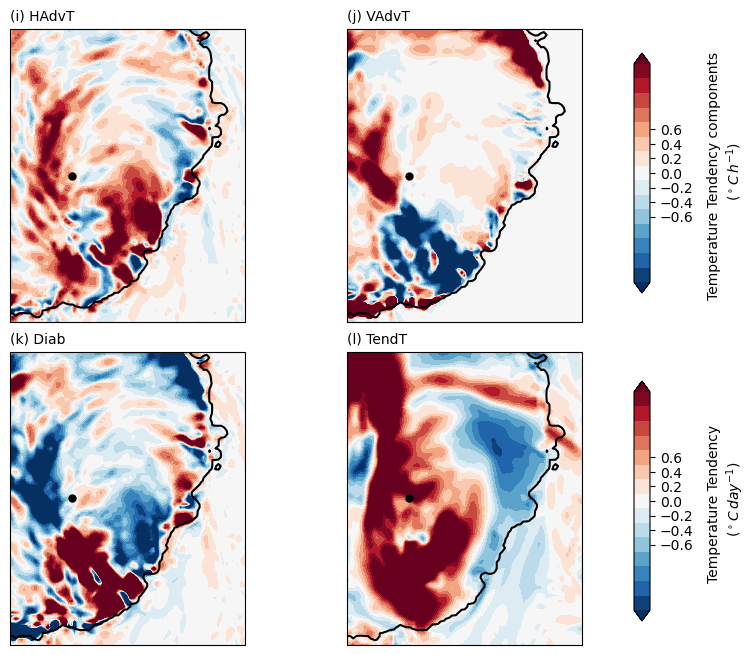

In [22]:
#############################################
# Plot Change in Temperature Tendency Equation components (level simga = 2)
#############################################

min_height = 10

time_ix_ini = np.where(times == np.datetime64('2022-03-17T00'))[0][0]
time_ix_end = np.where(times == np.datetime64('2022-03-18T00'))[0][0]
  
#################
### Plot Norm ###
#Figure and axis
fig = plt.figure(figsize=[8,8])
spec = gridspec.GridSpec(ncols=2, nrows=2, figure=fig, hspace= 0.1, wspace=0.1)

### Background
ax1 = fig.add_subplot(spec[0, 0], projection=ccrs.SouthPolarStereo())
ax2 = fig.add_subplot(spec[0, 1], projection=ccrs.SouthPolarStereo())
ax3 = fig.add_subplot(spec[1, 0], projection=ccrs.SouthPolarStereo())
ax4 = fig.add_subplot(spec[1, 1], projection=ccrs.SouthPolarStereo())

CS1 = ax1.contour(wrf.to_np(height), np.arange(10,9000,8000), cmap="gray", extend="both")
CS2 = ax2.contour(wrf.to_np(height), np.arange(10,9000,8000), cmap="gray", extend="both")
CS3 = ax3.contour(wrf.to_np(height), np.arange(10,9000,8000), cmap="gray", extend="both")
CS4 = ax4.contour(wrf.to_np(height), np.arange(10,9000,8000), cmap="gray", extend="both")

for ax in [ax1, ax2, ax3, ax4]:
    ax.plot(wrf.to_np(CON_xy)[0], wrf.to_np(CON_xy)[1], 'ko', markersize=5, color='k')
    #ax.plot(wrf.to_np(DDU_xy)[0], wrf.to_np(DDU_xy)[1], 'ko', markersize=5, color='k')
    #ax.plot(wrf.to_np(CIS_xy)[0], wrf.to_np(CIS_xy)[1], 'ko', markersize=5, color='k')

#Calculate difference between the beginning and the end of the event
Adv_ssp245_event = wrf.to_np(Adv_ssp245[time_ix_ini:time_ix_end,:,:].mean(axis=0)) - wrf.to_np(Adv_hist[time_ix_ini:time_ix_end,:,:].mean(axis=0))
VAdv_ssp245_event = wrf.to_np(VAdv_ssp245[time_ix_ini:time_ix_end,:,:].mean(axis=0)) - wrf.to_np(VAdv_hist[time_ix_ini:time_ix_end,:,:].mean(axis=0))
Res_ssp245_event = wrf.to_np(Res_ssp245[time_ix_ini:time_ix_end,:,:].mean(axis=0)) - wrf.to_np(Res_hist[time_ix_ini:time_ix_end,:,:].mean(axis=0))
Tend_ssp245_event = wrf.to_np(Tend_ssp245[time_ix_ini:time_ix_end,:,:].mean(axis=0)) - wrf.to_np(Tend_hist[time_ix_ini:time_ix_end,:,:].mean(axis=0))

fill1 = ax1.contourf(Adv_ssp245_event, np.arange(-1.5,1.55,0.2), cmap='RdBu_r', extend="both")
fill2 = ax2.contourf(VAdv_ssp245_event, np.arange(-1.5,1.55,0.2), cmap='RdBu_r', extend="both")
fill3 = ax3.contourf(Res_ssp245_event, np.arange(-1.5,1.55,0.2), cmap='RdBu_r', extend="both")
fill4 = ax4.contourf(Tend_ssp245_event*8, np.arange(-1.5,1.55,0.2), cmap='RdBu_r', extend="both")

ax1.set_title('(i) HAdvT', loc='left', fontsize=10)
ax2.set_title('(j) VAdvT', loc='left', fontsize=10)
ax3.set_title('(k) Diab', loc='left', fontsize=10)
ax4.set_title('(l) TendT', loc='left', fontsize=10)

fig.subplots_adjust(right=0.93)
cbar_ax_1 = fig.add_axes([0.95, 0.55, 0.02, 0.3])
cbar_1 = fig.colorbar(fill1, cax=cbar_ax_1, orientation = 'vertical', shrink=0.5, pad=0)
cbar_1.set_label('Temperature Tendency components \n ($^\circ C\, h^{-1}$)', labelpad=10)
cbar_1.set_ticks(np.arange(-0.6,0.61,0.2))

cbar_ax_2 = fig.add_axes([0.95, 0.14, 0.02, 0.3])
cbar_2 = fig.colorbar(fill4, cax=cbar_ax_2, orientation = 'vertical', shrink=0.5, pad=0)
cbar_2.set_label('Temperature Tendency \n ($^\circ C\, day^{-1}$)', labelpad=10)
cbar_2.set_ticks(np.arange(-0.6,0.61,0.2))


for ax in [ax1, ax2, ax3, ax4]:
    ax.set_extent([140, 220, 30, 130], crs=ccrs.SouthPolarStereo())
    ax.contourf(np.where(np.isnan(Res_ssp245_event), 1, 0), [0.1, 1000], cmap='Greys')

/tmp/ipykernel_129520/1419539137.py:28: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko" (-> color='k'). The keyword argument will take precedence.
  ax.plot(wrf.to_np(CON_xy)[0], wrf.to_np(CON_xy)[1], 'ko', markersize=5, color='k')


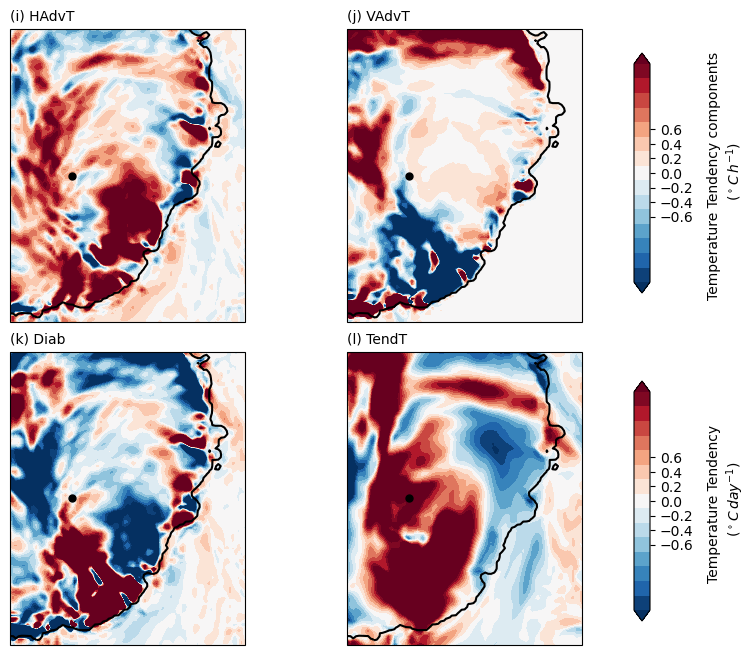

In [21]:
#############################################
# Plot Change in Temperature Tendency Equation components (level simga = 2)
#############################################

min_height = 10

time_ix_ini = np.where(times == np.datetime64('2022-03-17T00'))[0][0]
time_ix_end = np.where(times == np.datetime64('2022-03-18T00'))[0][0]
  
#################
### Plot Norm ###
#Figure and axis
fig = plt.figure(figsize=[8,8])
spec = gridspec.GridSpec(ncols=2, nrows=2, figure=fig, hspace= 0.1, wspace=0.1)

### Background
ax1 = fig.add_subplot(spec[0, 0], projection=ccrs.SouthPolarStereo())
ax2 = fig.add_subplot(spec[0, 1], projection=ccrs.SouthPolarStereo())
ax3 = fig.add_subplot(spec[1, 0], projection=ccrs.SouthPolarStereo())
ax4 = fig.add_subplot(spec[1, 1], projection=ccrs.SouthPolarStereo())

CS1 = ax1.contour(wrf.to_np(height), np.arange(10,9000,8000), cmap="gray", extend="both")
CS2 = ax2.contour(wrf.to_np(height), np.arange(10,9000,8000), cmap="gray", extend="both")
CS3 = ax3.contour(wrf.to_np(height), np.arange(10,9000,8000), cmap="gray", extend="both")
CS4 = ax4.contour(wrf.to_np(height), np.arange(10,9000,8000), cmap="gray", extend="both")

for ax in [ax1, ax2, ax3, ax4]:
    ax.plot(wrf.to_np(CON_xy)[0], wrf.to_np(CON_xy)[1], 'ko', markersize=5, color='k')
    #ax.plot(wrf.to_np(DDU_xy)[0], wrf.to_np(DDU_xy)[1], 'ko', markersize=5, color='k')
    #ax.plot(wrf.to_np(CIS_xy)[0], wrf.to_np(CIS_xy)[1], 'ko', markersize=5, color='k')

#Calculate difference between the beginning and the end of the event
Adv_ssp585_event = wrf.to_np(Adv_ssp585[time_ix_ini:time_ix_end,:,:].mean(axis=0)) - wrf.to_np(Adv_hist[time_ix_ini:time_ix_end,:,:].mean(axis=0))
VAdv_ssp585_event = wrf.to_np(VAdv_ssp585[time_ix_ini:time_ix_end,:,:].mean(axis=0)) - wrf.to_np(VAdv_hist[time_ix_ini:time_ix_end,:,:].mean(axis=0))
Res_ssp585_event = wrf.to_np(Res_ssp585[time_ix_ini:time_ix_end,:,:].mean(axis=0)) - wrf.to_np(Res_hist[time_ix_ini:time_ix_end,:,:].mean(axis=0))
Tend_ssp585_event = wrf.to_np(Tend_ssp585[time_ix_ini:time_ix_end,:,:].mean(axis=0)) - wrf.to_np(Tend_hist[time_ix_ini:time_ix_end,:,:].mean(axis=0))

fill1 = ax1.contourf(Adv_ssp585_event, np.arange(-1.5,1.55,0.2), cmap='RdBu_r', extend="both")
fill2 = ax2.contourf(VAdv_ssp585_event, np.arange(-1.5,1.55,0.2), cmap='RdBu_r', extend="both")
fill3 = ax3.contourf(Res_ssp585_event, np.arange(-1.5,1.55,0.2), cmap='RdBu_r', extend="both")
fill4 = ax4.contourf(Tend_ssp585_event*8, np.arange(-1.5,1.55,0.2), cmap='RdBu_r', extend="both")

ax1.set_title('(i) HAdvT', loc='left', fontsize=10)
ax2.set_title('(j) VAdvT', loc='left', fontsize=10)
ax3.set_title('(k) Diab', loc='left', fontsize=10)
ax4.set_title('(l) TendT', loc='left', fontsize=10)

fig.subplots_adjust(right=0.93)
cbar_ax_1 = fig.add_axes([0.95, 0.55, 0.02, 0.3])
cbar_1 = fig.colorbar(fill1, cax=cbar_ax_1, orientation = 'vertical', shrink=0.5, pad=0)
cbar_1.set_label('Temperature Tendency components \n ($^\circ C\, h^{-1}$)', labelpad=10)
cbar_1.set_ticks(np.arange(-0.6,0.61,0.2))

cbar_ax_2 = fig.add_axes([0.95, 0.14, 0.02, 0.3])
cbar_2 = fig.colorbar(fill4, cax=cbar_ax_2, orientation = 'vertical', shrink=0.5, pad=0)
cbar_2.set_label('Temperature Tendency \n ($^\circ C\, day^{-1}$)', labelpad=10)
cbar_2.set_ticks(np.arange(-0.6,0.61,0.2))


for ax in [ax1, ax2, ax3, ax4]:
    ax.set_extent([140, 220, 30, 130], crs=ccrs.SouthPolarStereo())
    ax.contourf(np.where(np.isnan(Res_ssp585_event), 1, 0), [0.1, 1000], cmap='Greys')